# Annealing Benchmarking and Verification

Here we apply our developed benchmarking strategy to annealers from DWave.

- sub-system: temperature, susceptibility, and flux noise
- system: ???
- application: QML

We will focus on the `advantage2_system1` solver:
- Zephyr graph with $m=12, t=4$
- around 5k qubits and 40k couplers
- biases $h\in [-6,6], J\in [-1,1]$

We will also tile jobs across all areas of the QPU, to compress the number of jobs.

> Note: we should set `auto_scale=False` throughout to ensure the `h,J` values we submit are respected.

## Background

Annealers solve Ising problems:

$$E(x)=\sum{h_ix_i}+\sum{J_{ij}x_ix_j}$$

The freeze-out point for a single qubit is around $s^*\approx 0.68$. Near that point, the distribution of qubit states is a thermal Boltzmann:

$$P(\text{state})\propto e^{-E/k_BT}$$

In [1]:
# imports
from scipy.constants import Planck, Boltzmann
from dwave.system import DWaveSampler
import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt
import time

from dwave.system.temperatures import (
    fast_effective_temperature,
    maximum_pseudolikelihood_temperature,
    maximum_pseudolikelihood,
    background_susceptibility_bqm,
    freezeout_effective_temperature,
    h_to_fluxbias,
)
from random import random
from dimod import BinaryQuadraticModel

In [2]:
# setup

SOLVER = "Advantage2_system1"

# device constants
# taken from the docs and the solver-properties spreadsheet

# B(s*): problem energy scale at single-qubit freeze-out
B_FREEZEOUT_GHZ = 8.06630607

# single-qubit freezeout point
S_STAR          = 0.684

# M_AFM (pH) for Advantage2_system1; used for h->flux conversion
MAFM_PH         = 0.528

In [3]:
# retrieve the working qubit graph
with DWaveSampler(solver=SOLVER) as sampler:
    G = sampler.to_networkx_graph()
print(f"working graph: {G.number_of_nodes()} qubits, {G.number_of_edges()} couplers")

working graph: 4577 qubits, 41514 couplers


## Sub-System Benchmarking

### Temperature

The higher the temperature, the noisier the qubits, i.e. the less likely they are to take the lowest-energy state.

There are two temperatures:

- effective temperature `w` is measured in bias units (same as $h$), and is returned by the DWave functions. We expect $w\approx0.112$
- physical temperature $T$ is in Kelvin and is converted using $T=B(s^*)2\pi\hbar w/2k_B$ with $B(s^*)\approx 8.066\text{ GHz}$. We expect $T\approx 20\text{ mK}$

Then, note that different subsets of qubits will have freeze at different points in the anneal, and thus will report different temperatures:

- single qubits
- coupled spin glass
- multi-qubit cluster

We will focus on single qubits here, but note that we can use clustering to probe the device at other points during the anneal. This has not been implemented yet.

We can measure temperature by fitting a Boltzmann distribution to the measured results:

$$\braket{\sigma_z}=\tanh{\frac{h_0-h}{w}}$$

Therefore, we will sweep $h$ (set all $J$ to 0), and measure the average spin at each. Then, we will fit the above function: the fitted distribution width $w$ is the effective temperature, and $h_0$ absorbs any other bias.

To get a good average, we can do this for a lot of qubits in a single job!

Once we have done the manual implementation, we will cross-check using DWave's own diagnostic functions.

In [ ]:
# setup
TARGET_QUBIT = 1
NUM_ANNEALS = 1000

# we concentrate the sweep near 0
_bias_seeds = np.logspace(-1.2, 0.4, 10) / 10
bias_values = np.array((-_bias_seeds).tolist()[::-1] + [0.0] + _bias_seeds.tolist())

# run, only on one qubit for now
results = []
with DWaveSampler(solver=SOLVER) as sampler:
    for bias in bias_values:
        h = {TARGET_QUBIT: bias}
        res = sampler.sample_ising(h, {}, num_reads=NUM_ANNEALS, label=f"bias={bias:.3f}", auto_scale=False)
        results.append(res)

Effective temperature: 0.112 +-0.003 (h0=-0.002 +-0.001)
Physical temperature: 21.68 +-0.63 mK


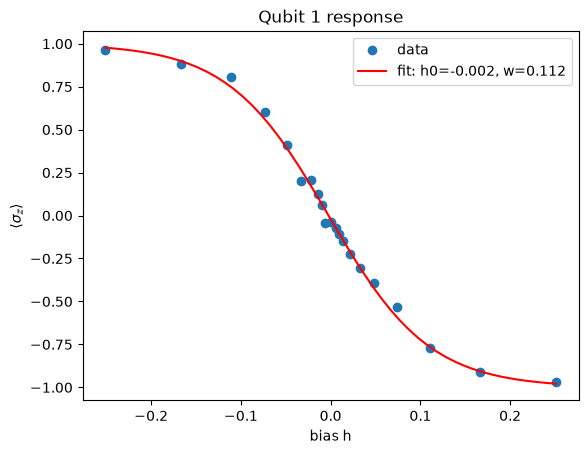

In [46]:
# analyse
avg_spins = [sum([s.sample[TARGET_QUBIT]*s.num_occurrences for s in i.data()])/NUM_ANNEALS for i in results]

def tanh_response(h, h0, w):
    return np.tanh((h0 - h) / w)

def w_to_kelvin(w):
    "Convert an effective temperature w (bias units) to physical temperature T (kelvin)."
    return B_FREEZEOUT_GHZ * 1e9 * Planck * w / (2 * Boltzmann)

popt, pcov = curve_fit(tanh_response, bias_values, avg_spins, p0=[0.0, 0.1])
perr = np.sqrt(np.diag(pcov))

w_tanh, w_tanh_err = popt[1], perr[1]

print(f"Effective temperature: {popt[1]:.3f} +-{perr[1]:.3f} (h0={popt[0]:.3f} +-{perr[0]:.3f})")
print(f"Physical temperature: {w_to_kelvin(popt[1])*1000:.2f} +-{w_to_kelvin(perr[1])*1000:.2f} mK")

plt.plot(bias_values, avg_spins, 'o', label='data')
plt.plot(np.linspace(min(bias_values), max(bias_values)), tanh_response(np.linspace(min(bias_values), max(bias_values)), *popt), 'r-', label=f'fit: h0={popt[0]:.3f}, w={popt[1]:.3f}')
plt.xlabel('bias h')
plt.ylabel(r'$\langle\sigma_z\rangle$')
plt.legend()
plt.title(f"Qubit {TARGET_QUBIT} response")
plt.show()


- `fast_effective_temperature` submits random single-qubit problems, should agree with our results
- `maximum_pseudolikelihood_temperature` experiments on a spin-glass (random $J$), which is a coupled problem with a different freezeout point, and so should have a higher effective temperature

In [ ]:
with DWaveSampler(solver=SOLVER) as sampler:
    w_fast, w_fast_err = fast_effective_temperature(
        sampler=sampler,
        sampler_params = {"num_reads": NUM_ANNEALS},
        nodelist = [TARGET_QUBIT],
        # num_bootstrap_samples=100
    )

    # we need to do a little config for the maximum pseudolikelihood temperature, since it expects a BQM
    bqm_sg = BinaryQuadraticModel.from_ising({}, {e: 1 - 2 * random() for e in sampler.edgelist})
    mpl_samples = sampler.sample(bqm_sg, num_reads=1000, auto_scale=False)
    w_mpl, _ = maximum_pseudolikelihood_temperature(bqm_sg, mpl_samples)

print(f"* fast: w = {w_fast:.4f}")
print(f"* MPL : w = {w_mpl:.4f}  (different freeze-out point)")

* fast: w = 0.1153 ± 0.0000
* MPL : w = 0.1303  (different freeze-out point)


### Susceptibility

$\chi$ is the "leakiness" of the qubits, acting through the couplers:

- a bias on one qubit leaks to the neighbours
- a qubit mediates a weak coupling between two of its neighbours

It modifies the implemented Hamiltonians thusly:

$$\text{BQM}=\text{BQM}(\chi=0)+\chi d\text{BQM}(\text{corrections})$$

Here we used a normalised $\chi=M_{\text{AFM}}\chi_q$ where $\chi_q=dIp/d\Phi_q$ is the _physical_ qubit susceptibility. 

Note that $\chi$ only has an effect when $J\neq 0$! Also, it has a dependency on $s$ and varies through the anneal.

We will measure this by building and sampling from a random spin-glass (zero biases, random couplers). Then, since the final distribution depends on the Hamiltonian, the temperature, and the susceptibility, we can pin the temperature to what we measured in the previous section (at zero couplings so there is no chi-effect) and measure the implied value of chi!

In [ ]:
NUM_ANNEALS = 2000

# create the spin glass
bqm = BinaryQuadraticModel.from_ising({}, {e: 1 - 2 * random() for e in sampler.edgelist})

# sample from it
with DWaveSampler(solver=SOLVER) as sampler:
    samples = sampler.sample(bqm, num_reads=NUM_ANNEALS, auto_scale=False)

# calculate the correction dBQM
dbqm = background_susceptibility_bqm(bqm)

# fit chi
x, _ = maximum_pseudolikelihood(
    bqms = [bqm, dbqm],
    sampleset = samples,
    x0 = [-1/w_fast, 0]
)

w_joint, chi = -1 / x[0], x[1] / x[0]

print(f"Measured chi: {chi:.4f}")
print(f"Seeded chi-free w_fast: {w_fast:.4f}")
print(f"Measured chi-corrected w_joint: {w_joint:.4f}")
print(f"w_joint / w_fast = {w_joint/w_fast:.4f} (close to 1 = trustworthy)")

Measured chi: -0.0178
Assumed chi-free w: 0.1153
Measured chi-corrected w: 0.1273
w_joint / w_fast = 1.1042 (close to 1 = trustworthy)


### $1/f$ Flux Noise

Each superconducting circuit suffers from $1/f$ flux noise causing the bias to drift. In other words, the power spectral density (how much noise occurs as a function of time scale) looks like

$$S(f)=\frac{A^2}{f^\alpha},\quad \alpha\approx0.7-1$$

$A$ is the amplitude of the noise at $1\text{ Hz}$. DWave corrects this drift hourly, so we need to turn that correction off.

To measure this, we set $h=J=0$, disable `flux_drift_compensation`, and record the mean spin as a time series. Then, we can analyse that and fit to extract $\alpha$. 

Again, using a cluster improves the signal.

Note that the longer we run the experiment, the more accuracy we have due to the Fourier conversion: the observable frequency band runs from $1/\text{duration}$ to $1/(s*\text{cadence})$

In [10]:
# sample every CADENCE s for DURATION s

CADENCE, DURATION = 2, 500
TARGET_QUBIT = 1
NUM_ANNEALS = 2000

print(f"Sampling every {CADENCE} s for {DURATION} s...")
print(f"Observable frequency band: {1/DURATION:.3f} Hz to {1/(2*CADENCE):.3f} Hz")
print(f"Expected number of jobs: {DURATION/CADENCE:.0f}")

bqm = BinaryQuadraticModel.from_ising({TARGET_QUBIT: 0}, {})

times = []
results = []

# run
with DWaveSampler(solver=SOLVER) as sampler:
    t0 = time.time()
    while time.time() - t0 < DURATION:
        t_ps = time.time()
        samples = sampler.sample(
            bqm,
            num_reads=NUM_ANNEALS,
            auto_scale=False,
            flux_drift_compensation=False,
            reduce_intersample_correlation=True
        )

        now = time.time()
        times.append(now - t0)
        results.append(samples)
        print(f"Sampled at t = {now - t0:.1f} s")

        time.sleep(max(0, CADENCE-(now-t_ps)))

Sampling every 2 s for 500 s...
Observable frequency band: 0.002 Hz to 0.250 Hz
Expected number of jobs: 250
Sampled at t = 0.0 s
Sampled at t = 2.0 s
Sampled at t = 4.0 s
Sampled at t = 6.0 s
Sampled at t = 8.0 s
Sampled at t = 10.0 s
Sampled at t = 12.0 s
Sampled at t = 14.0 s
Sampled at t = 16.0 s
Sampled at t = 18.0 s
Sampled at t = 20.0 s
Sampled at t = 22.0 s
Sampled at t = 24.0 s
Sampled at t = 26.0 s
Sampled at t = 28.0 s
Sampled at t = 30.0 s
Sampled at t = 32.0 s
Sampled at t = 34.0 s
Sampled at t = 36.0 s
Sampled at t = 38.0 s
Sampled at t = 40.0 s
Sampled at t = 42.0 s
Sampled at t = 44.0 s
Sampled at t = 46.0 s
Sampled at t = 48.0 s
Sampled at t = 50.0 s
Sampled at t = 52.0 s
Sampled at t = 54.0 s
Sampled at t = 56.0 s
Sampled at t = 58.0 s
Sampled at t = 60.0 s
Sampled at t = 62.0 s
Sampled at t = 64.0 s
Sampled at t = 66.0 s
Sampled at t = 68.0 s
Sampled at t = 70.0 s
Sampled at t = 72.0 s
Sampled at t = 74.0 s
Sampled at t = 76.0 s
Sampled at t = 78.0 s
Sampled at t = 8

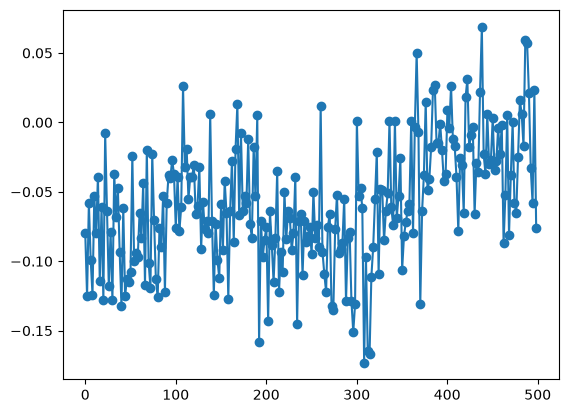

In [ ]:
spins = [sum([s.sample[TARGET_QUBIT]*s.num_occurrences for s in i.data()])/NUM_ANNEALS for i in results]

plt.plot(times, spins, 'o-')

# need to analyse this!